# Naive Bayes Classification to Predict Titanic Survival

**Deep Dive Coding Data Science Bootcamp Sample Project**

---
Robert Citek - October 5th, 2026


## Problem Definition

State the business problem. Translate the business problem into a Data Science problem by stating what kind of problem it is ( supervised vs unsupervised ) and whether it is a classification, regression, or clustering problem.  Mention which model will be used, if known.

In [95]:
# Business Problem: Predict whether a passenger survived. This is a classification problem. I will use Gaussian Naive Bayes (GNB)

## Data Collection/Sources

### Data Overview

This data comes from [Kaggle](https://www.kaggle.com/c/titanic/data), which was then copied to AWS for easy access.

https://ddc-datascience.s3.amazonaws.com/Projects/Example/Data/Titanic.train.csv


### Imports

In [96]:
from IPython.display import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

from sklearn import datasets, metrics, model_selection
from sklearn import model_selection
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

### File Paths

Create a variable `url` that contains the web link to the CSV data

In [97]:
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Example/Data/Titanic.train.csv' # insert url here
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Example/Data/Titanic.train.csv'

### Load data

Load the data into a data frame named `titanic_df`.

In [98]:
# load data
titanic_df = pd.read_csv(url)

### head

Look at the first few rows

In [99]:
# first few rows
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### tail

Look at the last few rows


In [100]:
# last few rows
titanic_df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### shape


In [101]:
# shape of data frame
titanic_df.shape

(891, 12)

### size


In [102]:
# size of data frame
titanic_df.size

10692

### Summary meta-data

Run the `info()` method on the data frame.


In [103]:
# display meta-data
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Summary statistics

Summary statistics give you a quick overview of the data.  Some items to spot check:
- the Target:
  - look for nulls
    - null will be culled
  - look at min, max, median, and mean
    - is it a categorical field masquerading as a number?
- the Features:
  - numerical
    - look at min, max, median, and mean
      - a min=1 and max=count suggests an ID
  - categorical
    - look at unique and freq
      - freq=1, unique=count suggests an ID
      - freq=count suggests a meaningless feature

Run the `describe()` method on the data frame.

In [104]:
# display summary statistics
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### target value_counts()


The target should be the first field that you look at.  Its data type will tell you what kind of machine learning problem this is ( classification or regression. ) Any nulls should be culled.  You can check for any skew in the data set.

In [105]:
# value_counts on target ; include nulls
titanic_df['Survived'].value_counts (dropna= False)

,count
Survived,
0,549
1,342


In [106]:
# normalized value_counts on target ; include nulls
titanic_df['Survived'].value_counts(normalize=True, dropna= False) *100

,proportion
Survived,
0,61.616162
1,38.383838


### Nulls



In [107]:
# look for nulls
titanic_df.isnull().sum().sort_values(ascending=False)

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


In [108]:
# look for nulls, displaying relative frequency- Option 1
null_sum=titanic_df.isnull().mean()
null_sum.sort_values()

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000
Embarked,0.002245


In [109]:
# look for nulls, displaying relative frequency- Option 2
null_sum=titanic_df.isnull().sum()
null_freq= null_sum/titanic_df.shape[0]
null_freq.sort_values()

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000
Embarked,0.002245


### dtypes - column data types

Which data types would be appropriate for Gaussian Naive Bayes?


In [110]:
# display data types
titanic_df.dtypes.sort_values()

,0
PassengerId,int64
Survived,int64
Pclass,int64
SibSp,int64
Parch,int64
Age,float64
Fare,float64
Name,object
Sex,object
Ticket,object


### Unique elements


If the total number of unique items in a field equals the number of rows, that suggests those fields are unique IDs ( e.g. names, IDs ) and should be dropped.


In [111]:
# number of unique elements in a column
titanic_df.nunique().sort_values(ascending=False)

,0
PassengerId,891
Name,891
Ticket,681
Fare,248
Cabin,147
Age,88
SibSp,7
Parch,7
Embarked,3
Pclass,3


## Data Cleaning


### Backup #1


In [112]:
# make backup
titanic_df_backup= titanic_df.copy()

In [113]:
# restore from backup
titanic_df=titanic_df_backup

### Keep only the target and two features

Select `Survived` for the target and `Age` and `Fare` for the features

In [114]:
# select the target and one feature
titanic_df_target_feature= titanic_df_backup[['Survived','Age','Fare']]
titanic_df_target_feature

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


### Backup #2


In [115]:
# make backup
titanic_df_target_feature_backup= titanic_df_target_feature.copy()

In [116]:
# restore from backup
titanic_df_target_feature =titanic_df_target_feature_backup

### Address any rows with nulls

- If the number of nulls in a column is low, it would be easiest to drop the row.
- If the number of nulls in a column is high, it would be easiest to drop the column.
- If the number of nulls in a column is between the low and high, one should impute values for the nulls.


#### Impute

In [117]:
titanic_df_target_feature.isnull().sum().sort_values (ascending=False)

,0
Age,177
Survived,0
Fare,0


Impute with the median.


In [118]:
# Calculate the median
median_age= titanic_df_target_feature['Age'].median()
median_age

28.0

In [119]:
# Assign median to nulls
titanic_df_target_feature['Age'].fillna(median_age, inplace=True)

/tmp/ipykernel_785/423404054.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df_target_feature['Age'].fillna(median_age, inplace=True)


In [120]:
# Verify there are no nulls
titanic_df_target_feature.isnull().sum()

,0
Survived,0
Age,0
Fare,0


In [121]:
# Verify median is about the same as before
titanic_df_target_feature.median()

,0
Survived,0.0000
Age,28.0000
Fare,14.4542


## Exploratory Data Analysis


GNB has two requirements:
1. the features are normally distributed
1. the features are not correlated with each other

### normal distribution of features: histogram


array([[<Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Fare'}>, <Axes: >]], dtype=object)

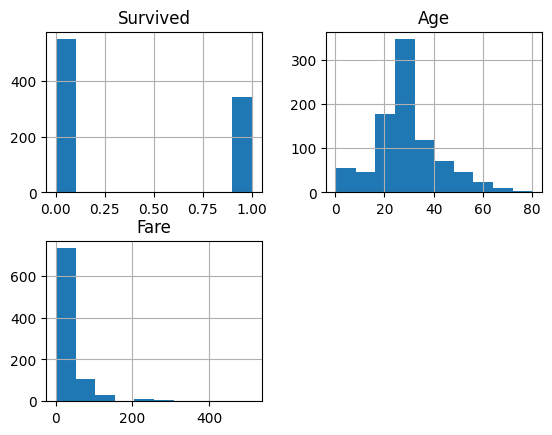

In [122]:
# Display a histogram
titanic_df_target_feature.hist()

### independence of features: correlation

In [123]:
#Correlation notes
  #Correlation means "moves together," not "causes." ex. Kids who are taller often weigh more. Height and weight move together. That is correlation.
  #GNB treats each feature as a separate clue. Age and Fare are barely linked, so GNB won't count the same clue twice.


In [124]:
# Calculate a correlation matrix
titanic_df_target_feature.corr()


# close to 1, strong correlation link.
# Age vs. Fare = 0.097 → almost no link
# Fare vs. Survived = 0.26 → small upward link
# Age vs. Survived = -0.065 → almost no link

,Survived,Age,Fare
Survived,1.000000,-0.064910,0.257307
Age,-0.064910,1.000000,0.096688
Fare,0.257307,0.096688,1.000000


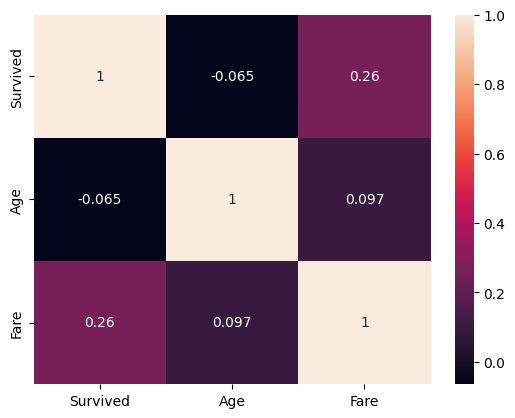

In [125]:
# Display the correlation matrix
sns.heatmap(titanic_df_target_feature.corr(), annot=True ) ;





## Processing



In [126]:
# Split data frame into target and features
target= titanic_df_target_feature['Survived']
features= titanic_df_target_feature[['Age','Fare']]

In [127]:
# Verify features
type(features)

pandas.core.frame.DataFrame

In [128]:
# Verify target
type(target)

pandas.core.series.Series

### Single Cross Validation ( CV )

Run a single Cross Validation

#### Train Test Split

In [129]:
# Train Test Split
x_train,x_test,y_train,y_test= train_test_split(features,target, test_size=0.25)

In [130]:
# Verify shape of each data set from Train Test Split
for i in (x_train, x_test,y_train,y_test):
  print(i.shape)
  print(type(i))

(668, 2)
<class 'pandas.core.frame.DataFrame'>
(223, 2)
<class 'pandas.core.frame.DataFrame'>
(668,)
<class 'pandas.core.series.Series'>
(223,)
<class 'pandas.core.series.Series'>


#### Model


In [131]:
# Create an empty GNB model
modelGNB= GaussianNB()

#### Fit



In [132]:
# Train ( fit ) the model
modelGNB.fit(x_train,y_train)


GaussianNB()

#### Prediction


In [133]:
# Make predicitons using the model
pred_result= modelGNB.predict(x_test)

#### Performance


We'll meassure accuracy, which is the proportions of the number correctly predicted, which is mathematically the same as one minus the proportion incorrectly predicted.

In [134]:
# Calculate the accuracy
accuracy=metrics.accuracy_score(y_test,pred_result)
accuracy*100


69.95515695067265

<Axes: >

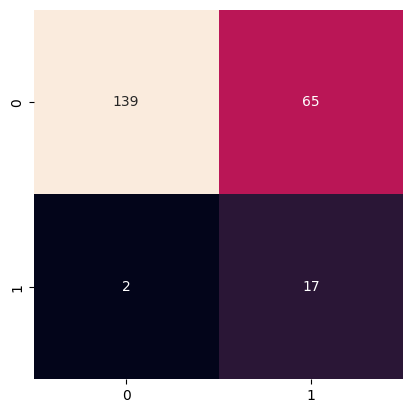

In [135]:
# Display a confusion matrix
mat = metrics.confusion_matrix(y_test,pred_result)
sns.heatmap(mat.T,
    square=True,
    annot=True,
    fmt='d',
    cbar=False,
)

### Multiple Cross Validation ( CV )

Create a CV loop with 100 iterations.  Capture performance metric in an array names `results`.
Use accuracy for the performance metric.


In [136]:
# Multiple CV loop
n=100
result=np.zeros(n)

for i in range(n):
  x_train, x_test, y_train, y_test= train_test_split(features,target,test_size=0.25)
  modelGNB = GaussianNB()
  modelGNB.fit(x_train,y_train)
  y_pred = modelGNB.predict(x_test)
  result[i]=metrics.accuracy_score(y_test,y_pred)

result



array([0.64573991, 0.65022422, 0.70403587, 0.66367713, 0.66816143,
       0.64573991, 0.65470852, 0.68161435, 0.65470852, 0.71300448,
       0.69955157, 0.632287  , 0.71300448, 0.67264574, 0.62331839,
       0.69506726, 0.65470852, 0.70403587, 0.70403587, 0.65919283,
       0.68161435, 0.69058296, 0.64125561, 0.632287  , 0.6367713 ,
       0.64125561, 0.66367713, 0.65470852, 0.65919283, 0.64573991,
       0.68161435, 0.68609865, 0.69058296, 0.70403587, 0.65022422,
       0.67713004, 0.64125561, 0.65470852, 0.65919283, 0.65919283,
       0.68609865, 0.68609865, 0.6367713 , 0.69955157, 0.64573991,
       0.632287  , 0.65470852, 0.67264574, 0.69506726, 0.70852018,
       0.67713004, 0.70403587, 0.69506726, 0.66816143, 0.66816143,
       0.65470852, 0.65919283, 0.65919283, 0.6367713 , 0.64573991,
       0.67264574, 0.7264574 , 0.64125561, 0.62331839, 0.70403587,
       0.70852018, 0.69506726, 0.68609865, 0.69058296, 0.69955157,
       0.65470852, 0.65919283, 0.64125561, 0.70403587, 0.60538

In [144]:
# Calculate mean of results
result.mean()

np.float64(0.6717488789237668)

<Axes: >

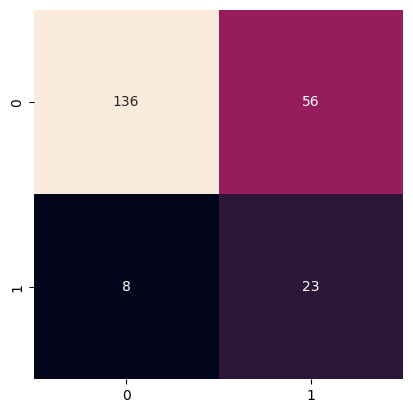

In [138]:
# Display a confusion matrix
mat= metrics.confusion_matrix(y_test,y_pred,)
sns.heatmap( mat.T,
    square=True,
    annot=True,
    fmt = "d",
    cbar = False,
)

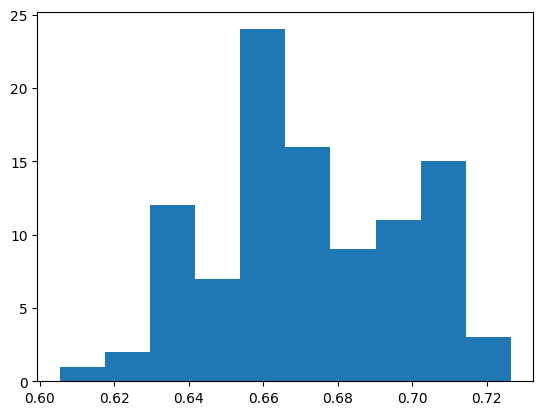

In [139]:
# Display a histogram of the results
plt.hist(result) ;

## Communication of Results

Conclusion:
  - one test scored, 70%,   - cell [134] calculate the accuracy cell
  - 100 random splits, 67%  - cell [137] calculate mean results


  Confusion matrix:
  - 136: guessed died, really died → right
  - 23: guessed survived, really survived → right
  - 56: guessed died, really survived → missed survivors
  - 8: guessed survived, really died → false alarms
  - Takeaway: The model mostly guesses "died." Age and Fare
     aren't strong enough clues to find survivors.

Future work:
  - Add stronger feature, like Sex and Pclass(ticket class)
  - Compare GNB model to another model on the same data

